# Stage 1 — basic version

**Toward Personalized Hebrew ASR** · Dolev Abudi, Hadas Yonat

The minimum needed to answer two questions:

1. How well does each model do **per speaker**?
2. What is each speaker's **adaptation gain** — how much does the Hebrew fine-tune help them?

| | model | inference dump |
|---|---|---|
| **A** | `openai/whisper-large-v3` (general) | `Dolevabudi/voxknesset-whisper-large-v3-baseline` |
| **B** | `ivrit-ai/whisper-large-v3-ct2` (Hebrew fine-tune) | `Dolevabudi/voxknesset-whisper-large-v3-ct2-inference` |

No filtering, no statistics, no modelling — those come later.

---
## 1. Load

In [1]:
import os, re, glob, unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rapidfuzz.distance import Levenshtein   # pip install rapidfuzz
from huggingface_hub import snapshot_download

C_A, C_B, C_GAIN = '#0072B2', '#D55E00', '#009E73'   # model A blue, B orange, gain green

C:\Users\hadas\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
path_a = snapshot_download('Dolevabudi/voxknesset-whisper-large-v3-baseline',
                           repo_type='dataset', allow_patterns=['data/*'])
path_b = snapshot_download('Dolevabudi/voxknesset-whisper-large-v3-ct2-inference',
                           repo_type='dataset', allow_patterns=['data/*'])

raw_a = pd.concat([pd.read_json(os.path.join(path_a, 'data', f), lines=True)
                   for f in ('train.jsonl', 'test.jsonl')], ignore_index=True)

shards = sorted(p for p in glob.glob(os.path.join(path_b, 'data', '*.parquet'))
                if 'results_10' not in os.path.basename(p))     # skip the 10-row pilot file
raw_b = pd.concat([pd.read_parquet(p) for p in shards], ignore_index=True)

print('A:', raw_a.shape, '| B:', raw_b.shape)
raw_a.head(2)

A: (66971, 15) | B: (66670, 15)


,filename,split,audio_seconds,latency_seconds,transcription,reference,error,speaker_id,age,gender,speaker_place_of_birth,speaker_year_of_aliya,speaker_religion,speaker_nationality,speaker_religious_orientation
0,30081_57020_3693_3725.wav,train,31.79,5.94,תודה רבה. תודה רבה לחבר הכנסת יואף קיש. אני לא...,תודה רבה לחבר הכנסת יואב קיש אני לא מבינה למה...,None,30081,54.360001,0,ברית המועצות,1991.0,יהודי,יהודי,חילוני
1,30081_57243_21203_21238.wav,train,34.73,6.93,Thank you very much. Shabbat shalom.,אייכלר חבר הכנסת ישראל אייכלר בבקשה אדוני חמ...,None,30081,54.369999,0,ברית המועצות,1991.0,יהודי,יהודי,חילוני


---
## 2. Pair the two dumps on the same audio

One wrinkle: dump A retried segments whose API call failed, so some filenames appear twice —
once with an error and once with the real transcription. Keep the good attempt.

In [3]:
a = raw_a.copy()
a['good'] = a.error.isna() & a.transcription.fillna('').str.strip().ne('')
a = a.sort_values('good', ascending=False).drop_duplicates('filename')

a = a[['filename', 'speaker_id', 'split', 'audio_seconds', 'reference', 'transcription',
       'age', 'gender']].rename(columns={'audio_seconds': 'duration_s',
                                         'reference': 'ref', 'transcription': 'hyp_A'})
b = raw_b[['filename', 'model_transcription']].rename(columns={'model_transcription': 'hyp_B'})

seg = a.merge(b, on='filename', how='inner')
print(f'{len(seg):,} paired segments, {seg.speaker_id.nunique()} speakers, '
      f'{seg.duration_s.sum()/3600:.0f} hours')
seg.head(2)

66,670 paired segments, 393 speakers, 2408 hours


,filename,speaker_id,split,duration_s,ref,hyp_A,age,gender,hyp_B
0,30081_57020_3693_3725.wav,30081,train,31.79,תודה רבה לחבר הכנסת יואב קיש אני לא מבינה למה...,תודה רבה. תודה רבה לחבר הכנסת יואף קיש. אני לא...,54.360001,0,תודה רבה. תודה רבה לחבר הכנסת יואב קיש. אני לא...
1,30701_87188_4066_4347.wav,30701,train,281.12,אדוני היושב ראש אדוני השר כנסת נכבדה מאז שהיית...,"בבקשה. אדוני יושב ראש, אדוני השר, כנסת נכבדה. ...",40.060001,1,"בבקשה. אדוני היושב-ראש, אדוני השר, כנסת נכבדה,..."


---
## 3. Normalise the Hebrew text

The protocol references have no punctuation; Whisper outputs punctuated Hebrew. Without this
step we would be scoring typography rather than recognition.

The one rule that is not obvious: geresh `׳` / gershayim `״` become a **space**, because the
protocol writes acronyms spaced out (`רמטכ ל`, `יו ש`). Deleting them instead would fuse two
reference words into one and create an error on every acronym in the corpus.

In [4]:
_niqqud = re.compile(r'[֑-ׇ]')                        # vowel points
_quotes = re.compile(r'[׳״"\'‘’“”]')
_dashes = re.compile(r'[־\-‐-―_/\\]')
_punct  = re.compile(r'[^\w\s֐-׿]', flags=re.UNICODE)

def normalize_he(s):
    if not isinstance(s, str):
        return ''
    s = unicodedata.normalize('NFKC', s)
    s = _niqqud.sub('', s)
    s = _quotes.sub(' ', s)      # -> space, see the note above
    s = _dashes.sub(' ', s)
    s = _punct.sub(' ', s)
    return re.sub(r'\s+', ' ', s).strip()

for src, dst in [('ref', 'ref_n'), ('hyp_A', 'hyp_A_n'), ('hyp_B', 'hyp_B_n')]:
    seg[dst] = seg[src].map(normalize_he)

print('REF :', seg.ref_n.iloc[0][:120])
print('A   :', seg.hyp_A_n.iloc[0][:120])
print('B   :', seg.hyp_B_n.iloc[0][:120])

REF : תודה רבה לחבר הכנסת יואב קיש אני לא מבינה למה יש רעש כזה גדול מצד המחנה הציוני או חברי הכנסת או הצוות נא להירגע בבקשה זה
A   : תודה רבה תודה רבה לחבר הכנסת יואף קיש אני לא מבינה למה יש רעש כזה גדול מצד מחנה הציוני או חברי כנסת או הצוות נע לי רגע ב
B   : תודה רבה תודה רבה לחבר הכנסת יואב קיש אני לא מבינה למה יש רעש כזה גדול מצד המחנה הציוני או החברי הכנסת או הצוות נא להירג


---
## 4. Error counts per segment

WER is the edit distance between the two **word sequences**, divided by the number of reference
words. CER is the same over characters.

We store raw error **counts**, not rates. That matters wherever we aggregate: a speaker's WER is
total errors ÷ total reference words, which is not the same as the average of their segment
WERs — that version would let a 20-word segment count as much as a 500-word one.

Counting here, *before* the filter in §5, is also what lets that section report the corpus WER
with and without the segments it removes.

In [5]:
seg['n_words'] = seg.ref_n.str.split().str.len()
seg['n_chars'] = seg.ref_n.str.len()

for tag in ('A', 'B'):
    hyp = seg[f'hyp_{tag}_n']
    seg[f'werr_{tag}'] = [Levenshtein.distance(r.split(), h.split())
                          for r, h in zip(seg.ref_n, hyp)]
    seg[f'cerr_{tag}'] = [Levenshtein.distance(r, h) for r, h in zip(seg.ref_n, hyp)]
    print(f'model {tag} done')

model A done


model B done


---
## 5. Drop segments whose reference does not match the audio

Some segments pair a long recording with a protocol excerpt covering only a fraction of it. The
worst is a **4.2-hour** file whose reference is **126 words**: the models transcribe the speech
correctly, but almost none of it appears in the reference, so every correctly recognised word is
charged as an insertion.

The filename decodes as `{speaker}_{session}_{start_sec}_{end_sec}.wav`, and a segment is the
contiguous span of session audio the protocol attributes to that speaker. No two speakers' spans
overlap anywhere in the corpus, so **nothing in the metadata can reveal that a file contains more
than one voice**. When the alignment breaks and hands one speaker the remainder of a sitting, the
only visible symptom is a span far too long to be a single turn.

### What not to use: a speaking-rate floor

The obvious test is reference words per minute, but it fails. A segment is a span of *time*, so
it includes the speaker's pauses — a chairman calling the next speaker manages 14 words in 42
seconds, and a rate-based rule discards that as if it were broken. Because the rule is a ratio,
its allowance shrinks to nothing for short references: at a 15 wpm floor, a 3-word reference is
thrown away once the audio passes 12 seconds.

### What we use: unexplained audio

Ask instead how many seconds of recording the reference cannot account for, *assuming the speaker
talks slowly* — 40 words per minute, or 1.5 s per word. Real speech here averages 108 wpm, so the
allowance is deliberately generous.

```
explained_s   = ref_words x 1.5
unexplained_s = duration_s - explained_s      ->  drop if more than 300 s
```

A **flat** 300-second allowance rather than a proportional one is the whole difference. Short
pausey segments keep their slack; a four-hour file holding 126 words does not.

It also tracks the quantity that does the damage. A rate ranks a 2-minute mismatch and a 4-hour
one as nearly the same; `unexplained_s` is, up to a constant, the number of spoken words the
reference fails to cover — which is exactly what gets charged against both models.

Because the error counts already exist (§4), the section closes with a table of the corpus WER
and CER with and without these segments — what the filter costs, and what it buys.

In [6]:
SLOW_WPM     = 40             # generous: real speech in this corpus averages ~108 wpm
SEC_PER_WORD = 60 / SLOW_WPM  # 1.5 s per word
MAX_UNEXPLAINED_S = 300       # 5 minutes of recording with no reference text at all

seg['wpm']           = seg.n_words / (seg.duration_s / 60)   # descriptive only, not the filter
seg['unexplained_s'] = seg.duration_s - seg.n_words * SEC_PER_WORD

print('seconds of audio the reference cannot account for:')
print(seg.unexplained_s.describe(percentiles=[.5, .9, .99, .999]).round(0).to_string())

keep    = seg.unexplained_s <= MAX_UNEXPLAINED_S
dropped = seg[~keep].copy()        # kept aside so the next cells can inspect what went
print(f'\ndropping {(~keep).sum()} of {len(seg):,} segments ({1 - keep.mean():.3%})')
print(f'speakers before: {seg.speaker_id.nunique()}   after: {seg[keep].speaker_id.nunique()}')

display(dropped.sort_values('unexplained_s', ascending=False)
        [['filename', 'duration_s', 'n_words', 'wpm', 'unexplained_s', 'werr_A', 'werr_B']].round(1))

seconds of audio the reference cannot account for:
count    66670.0
mean      -210.0
std        258.0
min      -3339.0
50%       -146.0
90%        -55.0
99%         -6.0
99.9%       80.0
max      33778.0

dropping 14 of 66,670 segments (0.021%)
speakers before: 393   after: 393


,filename,duration_s,n_words,wpm,unexplained_s,werr_A,werr_B
66669,12961_42189_27443_61267.wav,33824.7,31,0.1,33778.2,31,29
66667,30058_94999_5175_20215.wav,15040.1,126,0.5,14851.1,126,9189
66665,30693_85508_973_11567.wav,10593.8,39,0.2,10535.3,39,2
6069,12951_87610_5183_12087.wav,6903.4,103,0.9,6748.9,8939,10146
66668,12951_87610_18371_23419.wav,5047.5,61,0.7,4956.0,61,190
66666,488_61326_4322_7620.wav,3298.4,87,1.6,3168.0,87,16
3893,30660_88666_23424_25412.wav,1988.4,118,3.6,1811.4,71,175
23372,23632_98875_2691_4336.wav,1644.3,67,2.4,1543.8,1246,43
47449,532_79782_2907_3908.wav,1000.9,6,0.4,991.9,1127,70
23333,23632_108969_3136_3945.wav,809.0,11,0.8,792.5,30,2


In [7]:
dropped[dropped['speaker_id'] == 12961]

,filename,speaker_id,split,duration_s,ref,hyp_A,age,gender,hyp_B,ref_n,hyp_A_n,hyp_B_n,n_words,n_chars,werr_A,cerr_A,werr_B,cerr_B,wpm,unexplained_s
66669,12961_42189_27443_61267.wav,12961,train,33824.68,את הישיבה היא תתחדש מחר יום רביעי כ ד באייר ...,None,68.449997,1,"הישיבה תתחדש מחר, יום רביעי, כד באייר התשערה, ...",את הישיבה היא תתחדש מחר יום רביעי כ ד באייר הת...,,הישיבה תתחדש מחר יום רביעי כד באייר התשערה 13 ...,31,147,31,147,29,124,0.054989,33778.18


### What the removal does to the whole dataset

Three rows: the corpus as it arrives, the corpus we keep, and the handful of segments in between.

In [8]:
def corpus_scores(df):
    return pd.Series({
        'segments' : len(df),
        'ref_words': df.n_words.sum(),
        'WER_A'    : df.werr_A.sum() / df.n_words.sum(),
        'WER_B'    : df.werr_B.sum() / df.n_words.sum(),
        'CER_A'    : df.cerr_A.sum() / df.n_chars.sum(),
        'CER_B'    : df.cerr_B.sum() / df.n_chars.sum(),
    })

effect = pd.DataFrame({'before removal'      : corpus_scores(seg),
                       'after removal'       : corpus_scores(seg[keep]),
                       'the dropped segments': corpus_scores(dropped)}).T
effect[['segments', 'ref_words']] = effect[['segments', 'ref_words']].astype(int)
display(effect.round(4))

for tag in ('A', 'B'):
    err_drop, err_all = dropped[f'werr_{tag}'].sum(), seg[f'werr_{tag}'].sum()
    print(f'model {tag}:  {(~keep).mean():.3%} of the segments and '
          f'{dropped.n_words.sum() / seg.n_words.sum():.3%} of the reference words, '
          f'but {err_drop / err_all:.1%} of all word errors '
          f'({err_drop:,} of {err_all:,})')

seg = seg[keep].reset_index(drop=True)
print(f'\nkept {len(seg):,} segments')

,segments,ref_words,WER_A,WER_B,CER_A,CER_B
before removal,66670,15114360,0.2077,0.0998,0.1067,0.0588
after removal,66656,15112843,0.2068,0.0983,0.1058,0.0574
the dropped segments,14,1517,9.2287,14.6473,8.4704,13.5921


model A:  0.021% of the segments and 0.010% of the reference words, but 0.4% of all word errors (14,000 of 3,138,796)
model B:  0.021% of the segments and 0.010% of the reference words, but 1.5% of all word errors (22,220 of 1,508,180)

kept 66,656 segments


**Reading it.** The corpus WER hardly moves — 0.2077 → 0.2068 for model A, 0.0998 → 0.0983 for
model B. Fourteen segments holding 1,517 of 15.1 million reference words cannot shift an average,
and no filter working at this scale could.

The third row is where the damage shows. Those segments score a WER of **9.2** for A and **14.6**
for B — errors outnumber reference words nine- and fifteen-fold, because the models transcribe
speech the protocol excerpt never mentions and every such word is charged as an insertion. WER is
not bounded by 1 for exactly this reason. They hold 0.010% of the reference words but carry 0.4%
of model A's word errors and 1.5% of model B's: a 40-fold and 150-fold over-representation.

The two models are hit unevenly, and the 4.2-hour file of speaker 30058 shows why — model A
returned nothing at all for it (126 deletions, the entire reference) while model B transcribed
the speech in full (9,189 errors). B also has only half as large a total error budget to absorb
such a hit.

So the filter is not here to improve the headline WER — it cannot. It is here because these
errors are not spread thinly over the corpus but concentrated in a handful of speakers, where
they are large enough to invert that speaker's result. §8 shows one such case.

---
## 6. Overall, before looking at speakers

In [9]:
for tag, name in [('A', 'whisper-large-v3 (general)'), ('B', 'ivrit-ai whisper-large-v3 (FT)')]:
    wer = seg[f'werr_{tag}'].sum() / seg.n_words.sum()
    cer = seg[f'cerr_{tag}'].sum() / seg.n_chars.sum()
    print(f'{name:<34}  WER {wer:.4f}   CER {cer:.4f}')

whisper-large-v3 (general)          WER 0.2068   CER 0.1058
ivrit-ai whisper-large-v3 (FT)      WER 0.0983   CER 0.0574


---
## 7. Performance per speaker

The same calculation, grouped by speaker.

In [10]:
spk = seg.groupby('speaker_id').agg(
    n_seg   = ('filename', 'size'),
    hours   = ('duration_s', lambda s: s.sum() / 3600),
    n_words = ('n_words', 'sum'),
    n_chars = ('n_chars', 'sum'),
    werr_A  = ('werr_A', 'sum'), werr_B = ('werr_B', 'sum'),
    cerr_A  = ('cerr_A', 'sum'), cerr_B = ('cerr_B', 'sum'),
)
for tag in ('A', 'B'):
    spk[f'wer_{tag}'] = spk[f'werr_{tag}'] / spk.n_words
    spk[f'cer_{tag}'] = spk[f'cerr_{tag}'] / spk.n_chars
spk = spk.drop(columns=[c for c in spk.columns if 'err_' in c])

print(f'{len(spk)} speakers')
spk[['n_seg', 'hours', 'wer_A', 'wer_B', 'cer_A', 'cer_B']].describe().round(3)

393 speakers


,n_seg,hours,wer_A,wer_B,cer_A,cer_B
count,393.000,393.000,393.000,393.000,393.000,393.000
mean,169.608,6.068,0.213,0.098,0.111,0.057
std,232.371,7.507,0.094,0.029,0.078,0.021
min,1.000,0.017,0.097,0.033,0.034,0.012
25%,34.000,1.248,0.164,0.079,0.077,0.044
50%,90.000,3.368,0.197,0.095,0.096,0.054
75%,218.000,8.210,0.239,0.114,0.124,0.067
max,1810.000,65.849,1.270,0.242,1.051,0.188


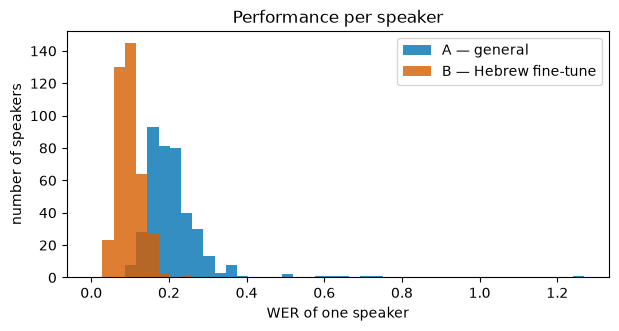

In [11]:
fig, ax = plt.subplots(figsize=(7, 3.2))
bins = np.linspace(0, spk.wer_A.max(), 45)
ax.hist(spk.wer_A, bins=bins, color=C_A, alpha=0.8, label='A — general')
ax.hist(spk.wer_B, bins=bins, color=C_B, alpha=0.8, label='B — Hebrew fine-tune')
ax.set_xlabel('WER of one speaker'); ax.set_ylabel('number of speakers')
ax.set_title('Performance per speaker'); ax.legend()
plt.show()

---
## 8. Adaptation gain per speaker

How much does the Hebrew fine-tune help each individual?

* `gain_abs` = WER_A − WER_B — WER points recovered
* `gain_rel` = gain_abs / WER_A — the fraction of the original error removed

In [12]:
spk['gain_abs'] = spk.wer_A - spk.wer_B
spk['gain_rel'] = spk.gain_abs / spk.wer_A

print(f'speakers helped by the fine-tune : {(spk.gain_abs > 0).sum()} / {len(spk)}')
print(f'speakers hurt by it              : {(spk.gain_abs < 0).sum()} / {len(spk)}')
print(f'median relative gain             : {spk.gain_rel.median():.1%}')
spk[['wer_A', 'wer_B', 'gain_abs', 'gain_rel']].describe().round(3)

speakers helped by the fine-tune : 393 / 393
speakers hurt by it              : 0 / 393
median relative gain             : 51.7%


,wer_A,wer_B,gain_abs,gain_rel
count,393.000,393.000,393.000,393.000
mean,0.213,0.098,0.115,0.524
std,0.094,0.029,0.082,0.086
min,0.097,0.033,0.047,0.186
25%,0.164,0.079,0.083,0.476
50%,0.197,0.095,0.099,0.517
75%,0.239,0.114,0.123,0.560
max,1.270,0.242,1.174,0.924


> **What the §5 filter bought.** Without it, speaker 30058 shows a `gain_rel` of **−1.70** and
> appears to be *hurt* by the fine-tune. The whole effect came from that one 4.2-hour segment:
> model B transcribed 9,293 words of real speech the 126-word protocol excerpt does not cover,
> and every one counted as an insertion — 82% of the speaker's total errors from a single
> segment. Model A only "won" there because its transcription of it was empty.
>
> With the filter that speaker is unremarkable: WER 0.171 → 0.086, a 50% gain like everyone
> else, and no speaker in the corpus is hurt by the fine-tune.

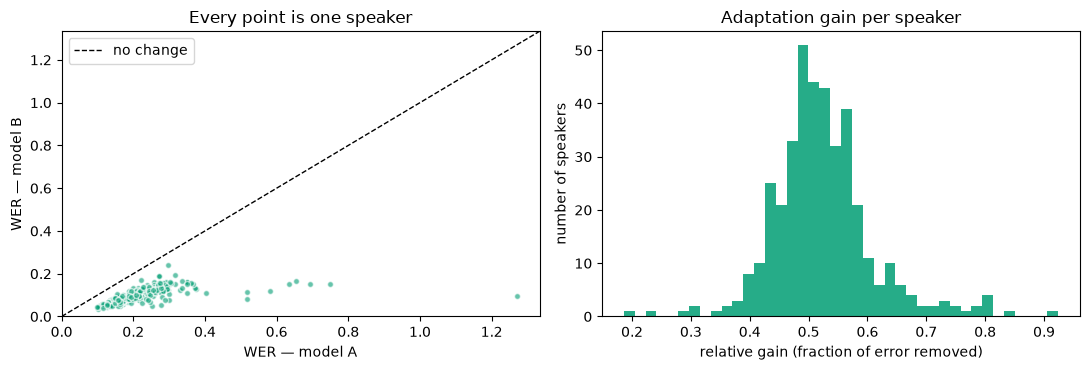

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

ax = axes[0]
lim = [0, spk.wer_A.max() * 1.05]
ax.plot(lim, lim, 'k--', lw=1, label='no change')
ax.scatter(spk.wer_A, spk.wer_B, s=18, color=C_GAIN, alpha=0.6, edgecolor='white')
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('WER — model A'); ax.set_ylabel('WER — model B')
ax.set_title('Every point is one speaker'); ax.legend()

ax = axes[1]
ax.hist(spk.gain_rel, bins=40, color=C_GAIN, alpha=0.85)
ax.set_xlabel('relative gain (fraction of error removed)')
ax.set_ylabel('number of speakers'); ax.set_title('Adaptation gain per speaker')
plt.tight_layout(); plt.show()

### Who gains most, and who gains least

Watch `n_seg` here — a speaker with only a handful of segments can land at either end of this
list by chance rather than for any real reason.

In [14]:
cols = ['n_seg', 'hours', 'wer_A', 'wer_B', 'gain_abs', 'gain_rel']
print('--- largest gain ---')
display(spk.nlargest(10, 'gain_rel')[cols].round(3))
print('--- smallest gain ---')
display(spk.nsmallest(10, 'gain_rel')[cols].round(3))

--- largest gain ---


,n_seg,hours,wer_A,wer_B,gain_abs,gain_rel
speaker_id,,,,,,
3263,2,0.214,1.270,0.096,1.174,0.924
10555,29,1.150,0.518,0.082,0.435,0.841
29855,1,0.056,0.252,0.050,0.201,0.800
448,123,6.411,0.748,0.150,0.599,0.800
30787,10,0.819,0.276,0.056,0.220,0.799
30816,9,0.649,0.582,0.118,0.465,0.798
12962,61,1.814,0.693,0.151,0.542,0.783
30095,40,1.803,0.517,0.113,0.404,0.782
22911,2,0.188,0.635,0.153,0.481,0.758


--- smallest gain ---


,n_seg,hours,wer_A,wer_B,gain_abs,gain_rel
speaker_id,,,,,,
30789,7,0.412,0.298,0.242,0.055,0.186
4298,13,0.563,0.222,0.170,0.052,0.235
30767,8,0.382,0.271,0.190,0.080,0.296
1033,38,1.357,0.270,0.187,0.083,0.307
30745,13,0.555,0.153,0.106,0.047,0.308
30698,3,0.200,0.199,0.132,0.067,0.338
30716,15,0.460,0.189,0.121,0.068,0.360
12936,294,9.523,0.212,0.134,0.078,0.367
464,17,0.739,0.257,0.161,0.096,0.373


---
## 9. WER against the amount of data per speaker

Does having more speech from a speaker go with better recognition? `n_seg` and `hours` measure
almost the same thing here (rho ≈ 0.98), so both panels should agree.

Note this is **not** about training data — no model was trained on these speakers as part of
this project. It asks whether prolific speakers are recognised differently, and it doubles as a
check on how much of the per-speaker spread is just measurement noise.

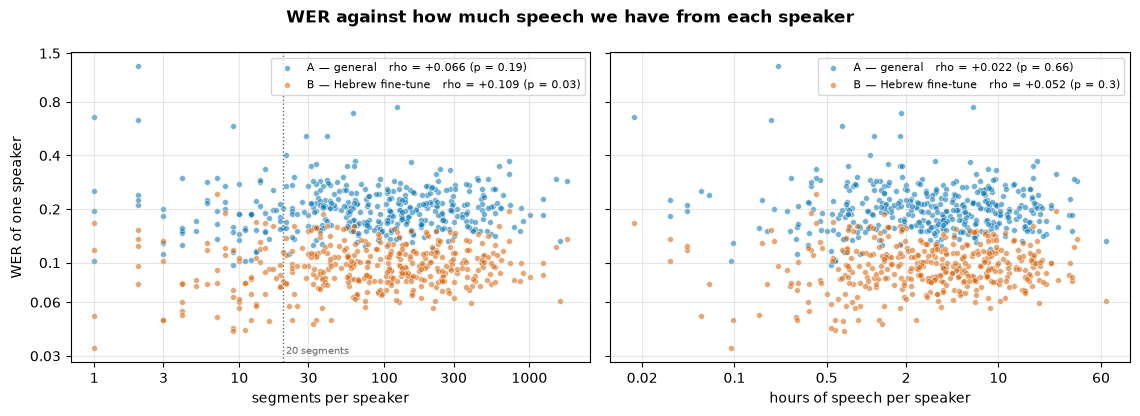

In [15]:
from scipy import stats
import matplotlib.ticker as mticker

def rho(x, y):
    r = stats.spearmanr(x, y)
    return r.statistic, r.pvalue

def decimal_log_axis(ax, ticks):
    ax.set_xscale('log')
    ax.xaxis.set_major_locator(mticker.FixedLocator(ticks))
    ax.xaxis.set_minor_locator(mticker.NullLocator())
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:g}'))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2), sharey=True)

for ax, col, label, ticks, cut in [
        (axes[0], 'n_seg', 'segments per speaker', [1, 3, 10, 30, 100, 300, 1000], 20),
        (axes[1], 'hours', 'hours of speech per speaker', [0.02, 0.1, 0.5, 2, 10, 60], None)]:
    for tag, colour, name in [('A', C_A, 'A — general'), ('B', C_B, 'B — Hebrew fine-tune')]:
        r, p = rho(spk[col], spk[f'wer_{tag}'])
        ax.scatter(spk[col], spk[f'wer_{tag}'], s=18, color=colour, alpha=0.55,
                   edgecolor='white', linewidth=0.6,
                   label=f'{name}   rho = {r:+.3f} (p = {p:.2g})')
    if cut is not None:                      # a segment count, so only meaningful on the left
        ax.axvline(cut, color='0.4', ls=':', lw=1)
        ax.text(cut, 0.02, f' {cut} segments', transform=ax.get_xaxis_transform(),
                fontsize=7.5, color='0.4', va='bottom')
    decimal_log_axis(ax, ticks)
    ax.set_yscale('log')
    ax.yaxis.set_major_locator(mticker.FixedLocator([0.03, 0.06, 0.1, 0.2, 0.4, 0.8, 1.5]))
    ax.yaxis.set_minor_locator(mticker.NullLocator())
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:g}'))
    ax.set_xlabel(label); ax.legend(fontsize=8, loc='upper right')
    ax.grid(alpha=0.3)

axes[0].set_ylabel('WER of one speaker')
fig.suptitle('WER against how much speech we have from each speaker',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

In [16]:
# The visible funnel: does the SPREAD shrink with more data, while the LEVEL stays flat?
bucket = pd.cut(spk.n_seg, [0, 5, 20, 50, 150, 400, 2000],
                labels=['1-5', '6-20', '21-50', '51-150', '151-400', '400+'])
tbl = spk.groupby(bucket, observed=True).agg(
    speakers=('wer_A', 'size'),
    median_wer_A=('wer_A', 'median'), sd_wer_A=('wer_A', 'std'),
    median_wer_B=('wer_B', 'median'), sd_wer_B=('wer_B', 'std'))
display(tbl.round(4))

,speakers,median_wer_A,sd_wer_A,median_wer_B,sd_wer_B
n_seg,,,,,
1-5,20,0.1889,0.2776,0.0764,0.0389
6-20,49,0.1865,0.0793,0.0833,0.0409
21-50,68,0.2089,0.0767,0.0956,0.0316
51-150,120,0.1923,0.0822,0.0939,0.0243
151-400,91,0.1983,0.0491,0.0958,0.0236
400+,45,0.2029,0.0583,0.0995,0.0255


### Reading it

**The level is flat.** Median WER barely moves across the buckets, and the correlations are near
zero. How much speech we have from a speaker does not predict how well either model does on
them.

**The spread is not flat.** The standard deviation of `wer_A` falls from about 0.28 among
speakers with 1–5 segments to about 0.06 among those with 400+. That funnel is the plot's real
content, and it is a **measurement** effect, not a property of the speakers: a WER computed on
two segments is mostly noise, and one computed on 400 is not.

That is what the dotted line at 20 segments marks, and why any statistical claim here
should be restricted to speakers above it. It is also why the extreme values in
this notebook's tables — the speaker at WER 1.27, the one-segment speaker with a 75% gain — sit
on the far left of these panels and should not be read as findings about those people.

---
## 10. Save

In [17]:
os.makedirs('outputs_basic', exist_ok=True)
spk.to_csv('outputs_basic/speaker_performance.csv', encoding='utf-8-sig')
print('wrote outputs_basic/speaker_performance.csv', spk.shape)
spk.head()

wrote outputs_basic/speaker_performance.csv (393, 10)


,n_seg,hours,n_words,n_chars,wer_A,cer_A,wer_B,cer_B,gain_abs,gain_rel
speaker_id,,,,,,,,,,
427,151,7.843186,45846,238595,0.254526,0.120564,0.105418,0.056041,0.149108,0.585826
433,38,1.436064,10527,52750,0.202147,0.106142,0.082075,0.048948,0.120072,0.593985
435,65,2.898922,13751,73767,0.216202,0.108951,0.101883,0.065178,0.114319,0.528759
445,578,18.296294,119053,622228,0.191184,0.094570,0.094353,0.057979,0.096831,0.506480
448,123,6.411167,34131,181924,0.748381,0.622853,0.149717,0.075773,0.598664,0.799945


---
## What this version deliberately leaves out

Each of these is a real issue. The point of stopping here is to see the basic numbers first.

* **only one filter** — §5 catches references that do not match their audio, but nothing checks
  the *transcription*; a decoder that loops and repeats a phrase is still counted in full
* **no minimum segment count** — some speakers have only one or two segments, so their WER is
  mostly noise. The highest speaker WER in the table comes from a speaker with **2 segments**,
  and is not a real result about that person
* **no variance or significance testing** — is the spread across speakers real, and does it
  differ between the two models?
* **no covariates** — age, gender, origin, speaking rate
* **the digit problem** — the protocol writes `שמונה`, Whisper writes `8`, and that counts as
  an error against both models